In [5]:
## Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [4]:
## Load & Inspect Dataset
df = sns.load_dataset('penguins')

print(df.shape) # 344 baris, 7 kolom
print(df.dtypes)
print(df.describe().round(2))

(344, 7)
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          342.00         342.00             342.00       342.00
mean            43.92          17.15             200.92      4201.75
std              5.46           1.97              14.06       801.95
min             32.10          13.10             172.00      2700.00
25%             39.22          15.60             190.00      3550.00
50%             44.45          17.30             197.00      4050.00
75%             48.50          18.70             213.00      4750.00
max             59.60          21.50             231.00      6300.00


In [9]:
## Verifikasi Daftar Spesies
print("Daftar Spesies:", df['species'].unique())
print("\nJumlah data per spesies:")
print(df['species'].value_counts())

Daftar Spesies: ['Adelie' 'Chinstrap' 'Gentoo']

Jumlah data per spesies:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


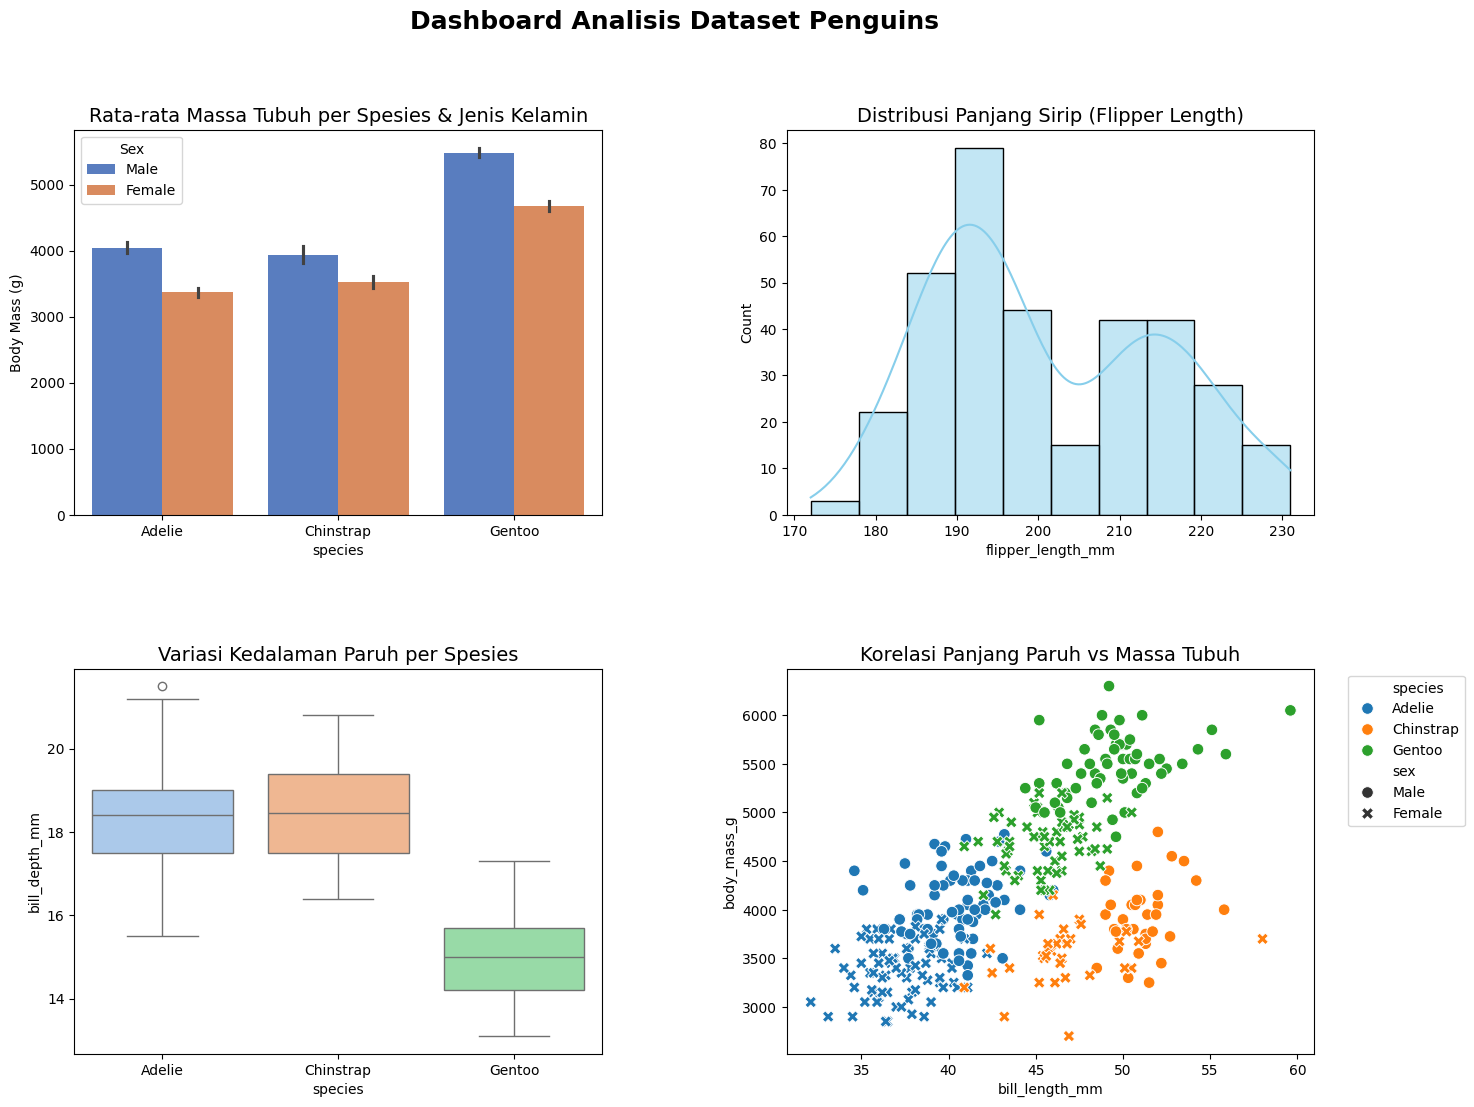

Dashboard telah diperbarui dan tersimpan sebagai dashboard_penguins.png


In [13]:
## Setup Figure Layout & Plotting
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Dashboard Analisis Dataset Penguins',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.4,
    wspace=0.35
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

## (1) Bar Chart - Average Body Mass per Species & Sex
sns.barplot(data=df, x='species', y='body_mass_g', hue='sex', ax=ax1, palette='muted')
ax1.set_title('Rata-rata Massa Tubuh per Spesies & Jenis Kelamin', fontsize=14)
ax1.set_ylabel('Body Mass (g)')
ax1.legend(title='Sex', loc='upper left')

## (2) Histogram - Distribution of Flipper Length
sns.histplot(data=df, x='flipper_length_mm', kde=True, ax=ax2, color='skyblue')
ax2.set_title('Distribusi Panjang Sirip (Flipper Length)', fontsize=14)

## (3) Boxplot - Bill Depth by Species
sns.boxplot(data=df, x='species', y='bill_depth_mm', ax=ax3, palette='pastel', hue='species', legend=False)
ax3.set_title('Variasi Kedalaman Paruh per Spesies', fontsize=14)

## (4) Scatter Plot - Bill Length vs Body Mass
sns.scatterplot(data=df, x='bill_length_mm', y='body_mass_g', hue='species', style='sex', ax=ax4, s=70)
ax4.set_title('Korelasi Panjang Paruh vs Massa Tubuh', fontsize=14)
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## EKSPOR (Harus sebelum plt.show)
plt.savefig(
    'dashboard_penguins.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Dashboard telah diperbarui dan tersimpan sebagai dashboard_penguins.png')

### **Analisis Dashboard Penguins**

#### **1. Rata-rata Massa Tubuh per Spesies & Jenis Kelamin (Bar Chart)**
*   **What?**: Terlihat perbedaan massa tubuh yang signifikan antar spesies (Gentoo sebagai yang terberat) dan antar jenis kelamin, di mana individu jantan secara konsisten lebih berat daripada betina di semua spesies (misal: Jantan Gentoo ~5.500g vs Betina ~4.700g).
*   **So what?**: Hal ini menunjukkan bahwa massa tubuh tidak hanya dipengaruhi oleh faktor genetik spesies, tetapi juga oleh dimorfisme seksual yang kuat, yang penting untuk pemantauan kesehatan populasi berdasarkan profil biologis yang lebih spesifik.
*   **Now what?**: Eksplorasi apakah massa tubuh ini dipengaruhi oleh lokasi pulau atau ketersediaan makanan di pulau tertentu. Serta gunakan variabel 'sex' sebagai fitur wajib jika ingin membangun model klasifikasi atau regresi untuk memprediksi karakteristik penguin.

#### **2. Distribusi Flipper Length (Histogram)**
*   **What?**: Data menunjukkan distribusi bimodal (dua puncak) dengan konsentrasi pada rentang 190-200mm dan puncak kedua di sekitar 210-220mm.
*   **So what?**: Ini mengonfirmasi adanya dua kelompok ukuran besar di populasi kita (kemungkinan besar pemisahan antara Gentoo yang berukuran besar dan spesies lainnya).
*   **Now what?**: Lakukan uji korelasi statistik antara panjang sirip dan kemampuan berenang atau efisiensi mencari makan.

#### **3. Variasi Kedalaman Paruh (Boxplot)**
*   **What?**: Adelie dan Chinstrap memiliki paruh yang lebih tebal/dalam (median > 18mm), sedangkan Gentoo memiliki paruh yang lebih ramping (median < 16mm).
*   **So what?**: Meskipun Gentoo paling besar secara fisik, paruhnya paling ramping. Ini menunjukkan spesialisasi cara makan atau jenis mangsa yang berbeda.
*   **Now what?**: Teliti hubungan antara kedalaman paruh dengan jenis diet utama masing-masing spesies.

#### **4. Korelasi Panjang Paruh vs Massa Tubuh (Scatter Plot)**
*   **What?**: Terdapat korelasi positif yang kuat; semakin panjang paruh (mencapai 59.6mm), semakin besar massa tubuhnya. Terlihat juga pengelompokan (clustering) yang jelas antar spesies.
*   **So what?**: Model regresi linier dapat dibangun untuk memprediksi berat badan penguin hanya berdasarkan dimensi paruhnya dengan tingkat akurasi tinggi.
*   **Now what?**: Analisis lebih lanjut apakah faktor 'Sex' (jantan/betina) menyebabkan pergeseran signifikan dalam kelompok yang sama (dimorfisme seksual).